In [1]:
from datetime import timedelta
import ggcmpy
from ggcmpy.timeseries import read_ggcm_solarwind_directory, store_to_pyspedas
import matplotlib.pyplot as plt
from matplotlib import colors
import pandas as pd
import numpy as np
import pathlib
import pyspedas
from pyspedas import options, tplot, get_data, store_data, tplot_names
import xarray as xr

In [2]:
trange = ["1997-01-10/00:00:00", "1997-01-10/14:00:00"]

# Download OMNI data.
pyspedas.omni.data(trange=trange, datatype="1min", time_clip=True)

10-Mar-26 19:39:46: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/omni/omni_cdaweb/hro_1min/1997/
10-Mar-26 19:39:47: File is current: omni_data/hro_1min/1997/omni_hro_1min_19970101_v01.cdf


['IMF',
 'PLS',
 'IMF_PTS',
 'PLS_PTS',
 'percent_interp',
 'Timeshift',
 'RMS_Timeshift',
 'RMS_phase',
 'Time_btwn_obs',
 'F',
 'BX_GSE',
 'BY_GSE',
 'BZ_GSE',
 'BY_GSM',
 'BZ_GSM',
 'RMS_SD_B',
 'RMS_SD_fld_vec',
 'flow_speed',
 'Vx',
 'Vy',
 'Vz',
 'proton_density',
 'T',
 'Pressure',
 'E',
 'Beta',
 'Mach_num',
 'Mgs_mach_num',
 'x',
 'y',
 'z',
 'BSN_x',
 'BSN_y',
 'BSN_z',
 'AE_INDEX',
 'AL_INDEX',
 'AU_INDEX',
 'SYM_D',
 'SYM_H',
 'ASY_D',
 'ASY_H',
 'PC_N_INDEX']

In [3]:
# Set the plotting style.
plt.style.use("seaborn-v0_8-whitegrid")

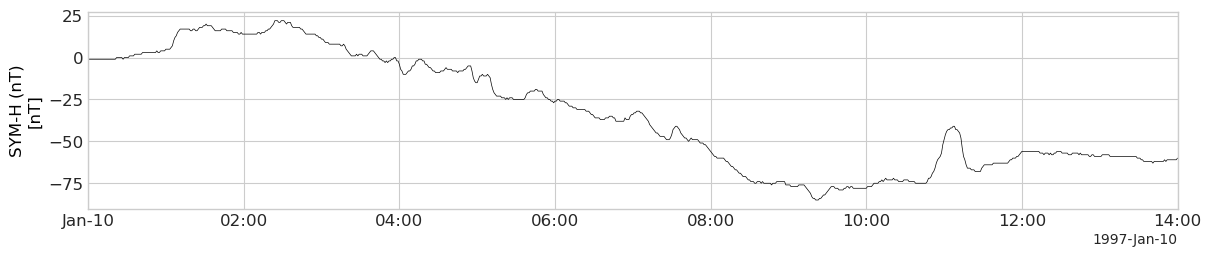

In [4]:
# Plot the SYM-H index.
options("SYM_H", "ytitle", "SYM-H (nT)")

vars_to_plot = ["SYM_H"]
tplot(vars_to_plot, trange, ysize=2.54 * len(vars_to_plot))

In [5]:
# Extract data.
time_sym_h, data_sym_h = get_data("SYM_H")
time_al_index, data_al_index = get_data("AL_INDEX")

# Create a DataFrame.
df = pd.DataFrame(
    {"Time": time_sym_h, "SYM-H": data_sym_h, "AL Index": data_al_index}
)

# Set index to datetime for easier slicing.
df["Time"] = pd.to_datetime(df["Time"], unit="s")
df.set_index("Time", inplace=True)

In [6]:
# Classify storms into four categories.
def classify_storm(min_sym_h):
    if min_sym_h <= -250:
        return "Super"
    elif min_sym_h <= -100:
        return "Large"
    elif min_sym_h <= -50:
        return "Moderate"
    elif min_sym_h <= -30:
        return "Small"
    else:
        return "Quiet"


storms = []
threshold = -30
window_hours = 48  # Group events within 48 hours as one storm.

active_periods = df[df["SYM-H"] <= threshold]

if not active_periods.empty:
    # Group active times into discrete events.
    gaps = active_periods.index.to_series().diff() > timedelta(
        hours=window_hours
    )
    event_ids = gaps.cumsum()

    for _, group in active_periods.groupby(event_ids):
        # Define the event window.
        start = group.index.min()
        end = group.index.max()

        # Grab a slightly larger slice to ensure we see the full picture.
        storm_slice = df[
            start - timedelta(hours=12) : end + timedelta(hours=12)
        ]

        # Calculate the minimum.
        min_sym_h_val = storm_slice["SYM-H"].min()
        min_sym_h_time = storm_slice["SYM-H"].idxmin()

        storms.append(
            {
                "Classification": classify_storm(min_sym_h_val),
                "Min SYM-H (nT)": min_sym_h_val,
                "Min SYM-H Time (UT)": min_sym_h_time,
            }
        )

In [7]:
# Display the result in a table.
results = pd.DataFrame(storms)
print(f"The number of storms identified: {len(results)}")
display(results)

The number of storms identified: 1


,Classification,Min SYM-H (nT),Min SYM-H Time (UT)
0,Moderate,-85,1997-01-10 09:21:00


In [8]:
# Check each storm for Sudden Storm Commencements.
for i, row in results.iterrows():
    peak_time = row["Min SYM-H Time (UT)"]
    classification = row["Classification"]

    # Define search window: 48 hours before the peak
    start_search = peak_time - timedelta(hours=48)
    end_search = peak_time

    window_df = df[start_search:end_search].copy()
    window_df["Delta_SYM-H"] = window_df["SYM-H"].diff()

    # Check for SSC Condition: An increase of >= 20 nT SYM-H in one hour
    ssc_candidates = window_df[window_df["Delta_SYM-H"] >= 20]

    print(f"\nStorm {i}: {classification}")
    print(f"  - Peak time: {peak_time}")
    print(f"  - Peak SYM-H: {row['Min SYM-H (nT)']} nT")

    if not ssc_candidates.empty:
        print(f"  - Potential SSC(s) found:")
        for t, jump in zip(
            ssc_candidates.index, ssc_candidates["Delta_SYM-H"]
        ):
            print(f"    * {t}: +{jump:.1f} nT jump")
    else:
        print("  - No SSC (> 20 nT jump within an hour) detected.")


Storm 0: Moderate
  - Peak time: 1997-01-10 09:21:00
  - Peak SYM-H: -85 nT
  - No SSC (> 20 nT jump within an hour) detected.


In [9]:
# Add OpenGGCM data.
RUN_NAME = "251118_1330_c030_AZ"
RUN_DIR = pathlib.Path("/mnt/home/germaschewski/cu1010/runs") / RUN_NAME
SW_DIR = RUN_DIR / "inp"
DATA_DIR = RUN_DIR / "target"

In [10]:
# OpenGGCM input data
wi = read_ggcm_solarwind_directory(SW_DIR, glob="wi.*")
store_to_pyspedas(wi)

In [11]:
# OpenGGCM ionosphere output
files = sorted(DATA_DIR.glob(f"{RUN_NAME}.iof.*00"))
iof = xr.open_mfdataset(files)

10-Mar-26 19:40:00: /tmp/ipykernel_764543/705686291.py:3: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  iof = xr.open_mfdataset(files)



In [12]:
# Calculate the AL index.
ggcm_al = iof.ggcm.al_index()
ggcmpy.timeseries.store_to_pyspedas(ggcm_al["ggcm.al"])
pyspedas.store_data("al", data=["AL_INDEX", "ggcm.al"])

True

In [13]:
# Calculate the cross-polar-cap-potential.
cpcp = iof.ggcm.cpcp() * 1e-3
cpcp.attrs["long_name"] = "CPCP"
cpcp.attrs["units"] = "kV"
store_to_pyspedas(cpcp)

In [14]:
# Calculate Joule heating.
jh = iof.ggcm.jh() * 1e-9
jh.attrs["units"] = "GW"
store_to_pyspedas(jh)

In [15]:
# Set plotting options.

# IMF Bz
options("BZ_GSE", "yrange", [-20, 20])
options("BZ_GSE", "ytitle", "IMF Bz")

# Solar Wind Speed
options("flow_speed", "ytitle", "Speed")

# Solar Wind Density
options("proton_density", "ylog", True)
options("proton_density", "yrange", [1, 100])
options("proton_density", "ytitle", "Density")

# Flow Pressure (Dynamic Pressure)
options("Pressure", "ytitle", "Dyn. Pressure")

# AE Index
options("AE_INDEX", "ytitle", "AE Index")

# AL Index
options("al", "yrange", [-2000, 0])
options("al", "ytitle", "AL Index")
options("al", "color", ["black", "red"])
options("al", "legend_names", ["OMNI", "OpenGGCM"])
options("al", "legend_location", "lower right")

# CPCP
options("cpcp", "yrange", [0, 700])
options("cpcp", "legend_names", "OpenGGCM")
options("cpcp", "legend_location", "upper right")

# Joule heating
options("jh", "ylog", True)
options("jh", "yrange", [1, 10000])
options("jh", "legend_names", "OpenGGCM")
options("jh", "legend_location", "upper right")

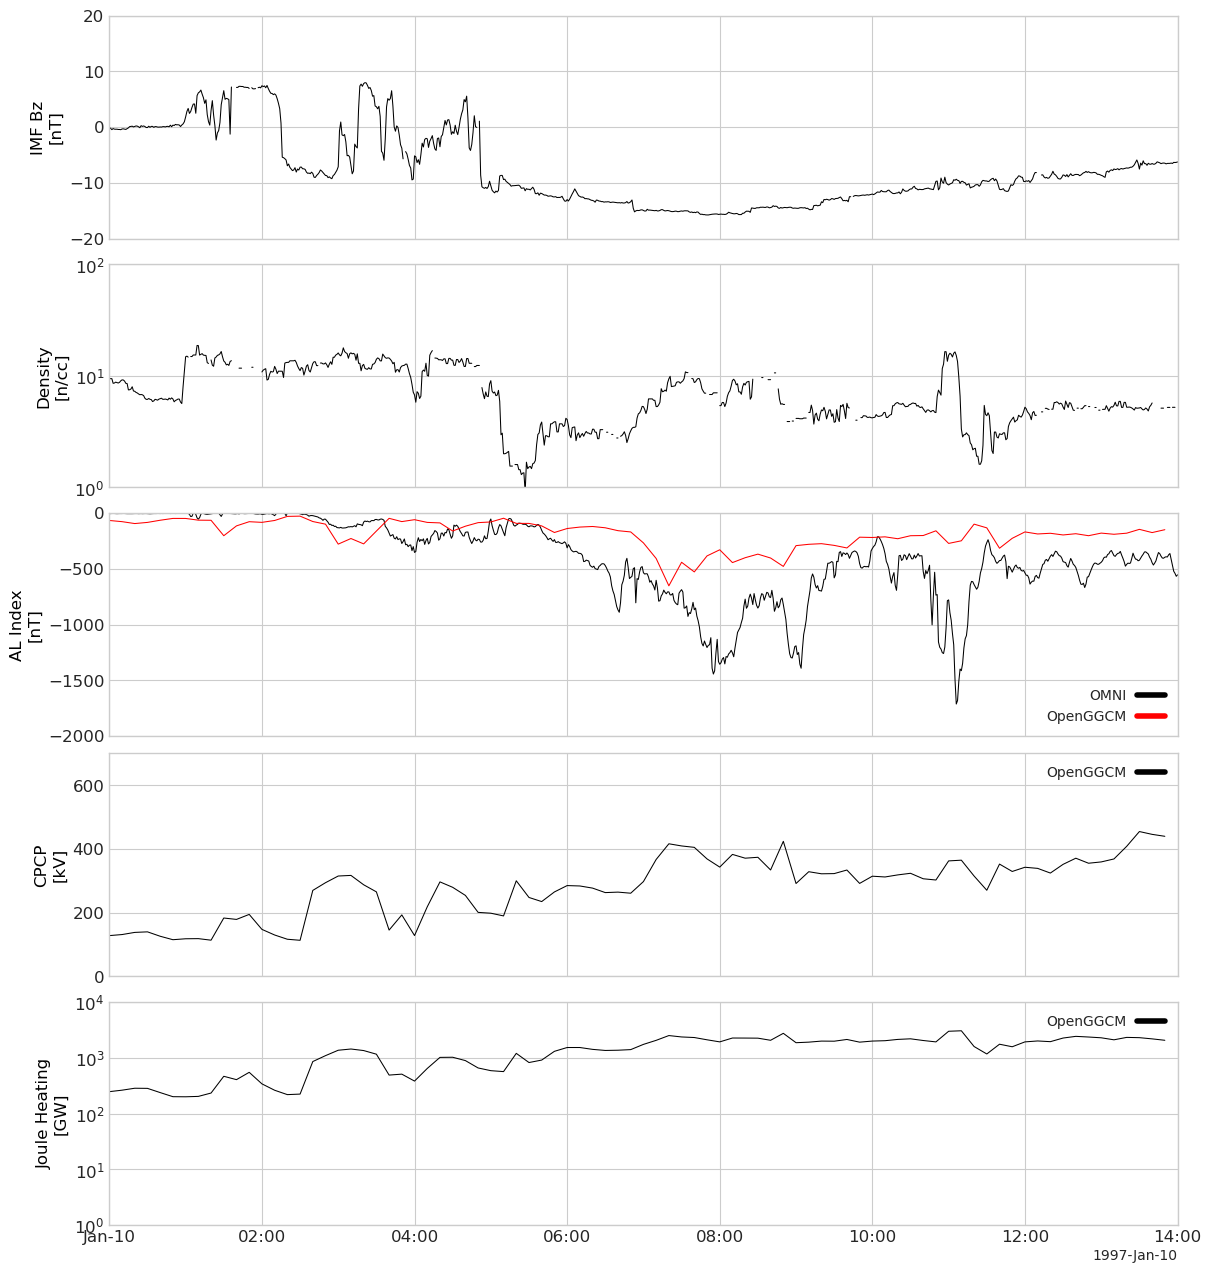

In [16]:
vars_to_plot = [
    "BZ_GSE",
    "proton_density",
    # "flow_speed",
    # "SYM_H",
    "al",
    "cpcp",
    "jh",
]

options(vars_to_plot, "alpha", 1.0)
options(vars_to_plot, "line_width", 0.75)

# Plot the geomagnetic data.
tplot(vars_to_plot, trange, ysize=2.54 * len(vars_to_plot))

In [17]:
files = sorted(DATA_DIR.glob(f"{RUN_NAME}.py_0.*"))
py_0 = xr.open_mfdataset(files)

10-Mar-26 19:40:59: /tmp/ipykernel_764543/1573920227.py:2: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  py_0 = xr.open_mfdataset(files)



In [18]:
# Determine the maximum time step.
time_max = iof.time.shape[0]

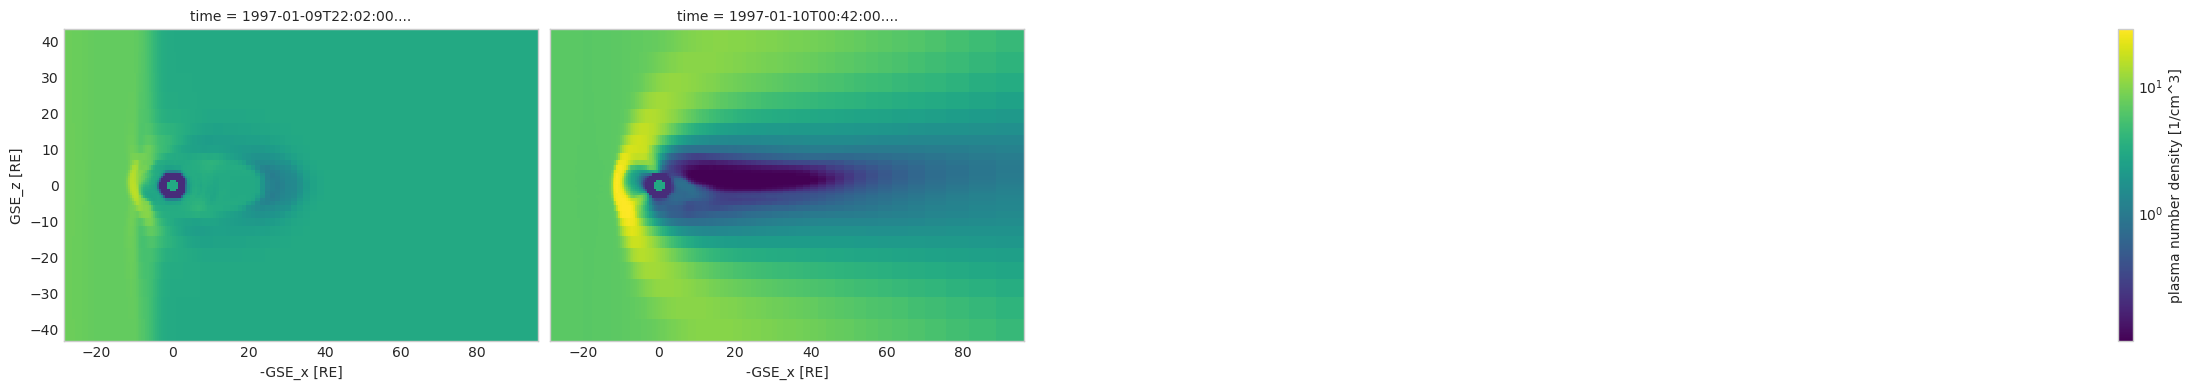

In [19]:
# Density
py_0.rr.sel(x=slice(-50.0, 100.0), z=slice(-50.0, 50.0)).isel(
    time=slice(0, time_max, 80)
).T.plot(col="time", col_wrap=4, aspect=1.5, size=4, norm=colors.LogNorm());

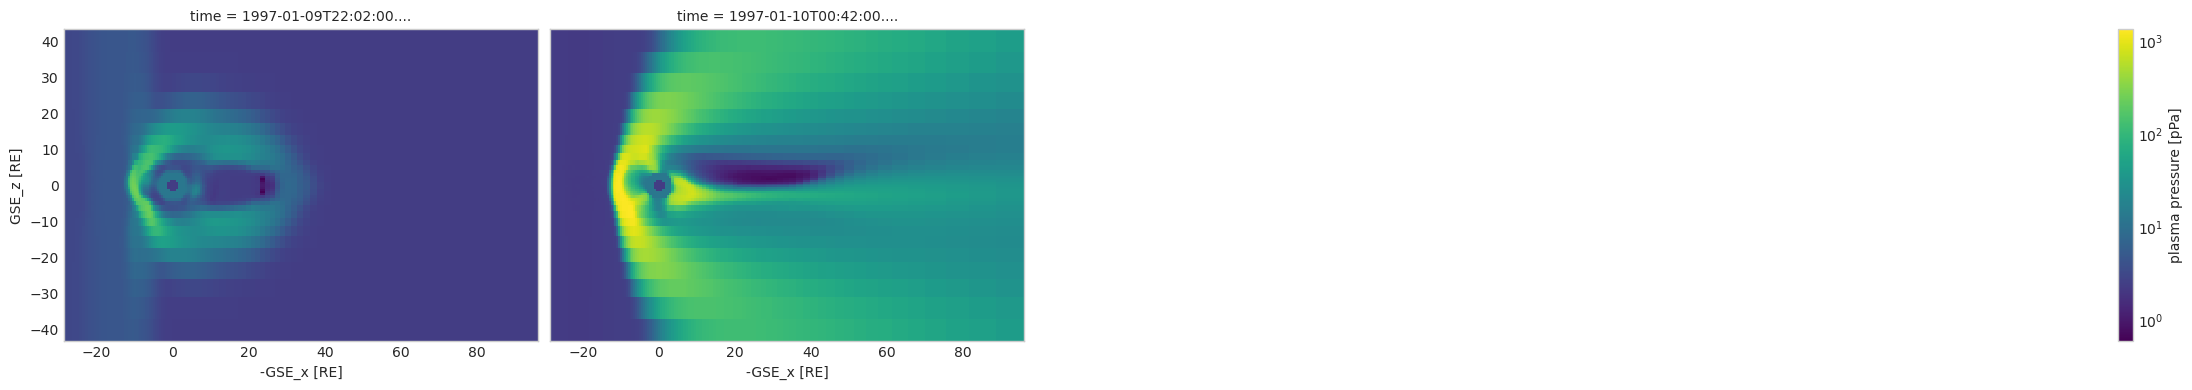

In [20]:
# Pressure
py_0.pp.sel(x=slice(-50.0, 100.0), z=slice(-50.0, 50.0)).isel(
    time=slice(0, time_max, 80)
).T.plot(col="time", col_wrap=4, aspect=1.5, size=4, norm=colors.LogNorm());

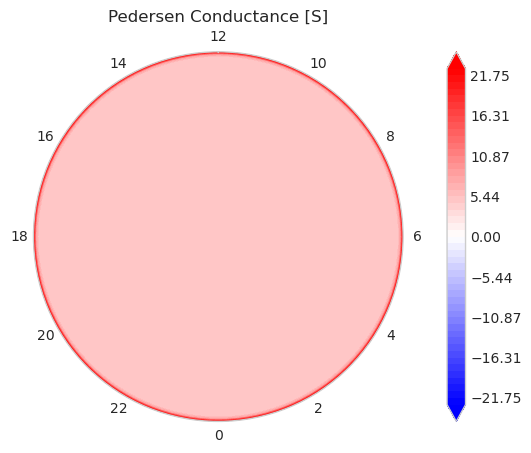

In [21]:
# Pedersen and Hall conductances
for i in range(1, time_max, 160):
    iof.isel(time=i).sigp.ggcm.plot()

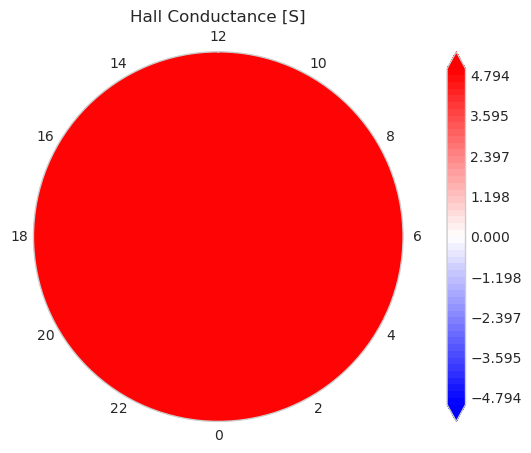

In [22]:
for i in range(1, time_max, 160):
    iof.isel(time=i).sigh.ggcm.plot()

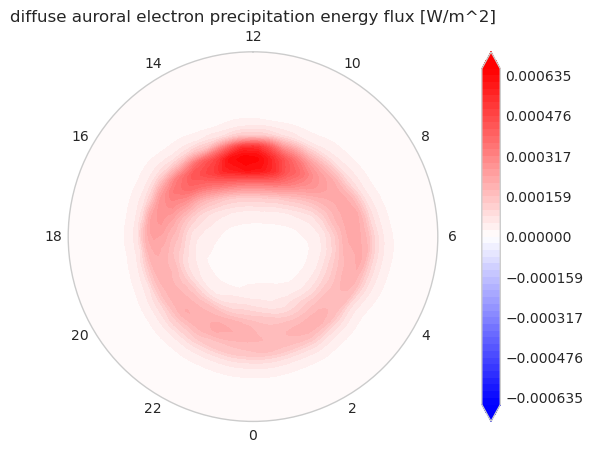

In [23]:
# Diffuse and discrete electron precipitation energy flux
for i in range(1, time_max, 160):
    iof.isel(time=i).prec_e_fe_1.ggcm.plot()

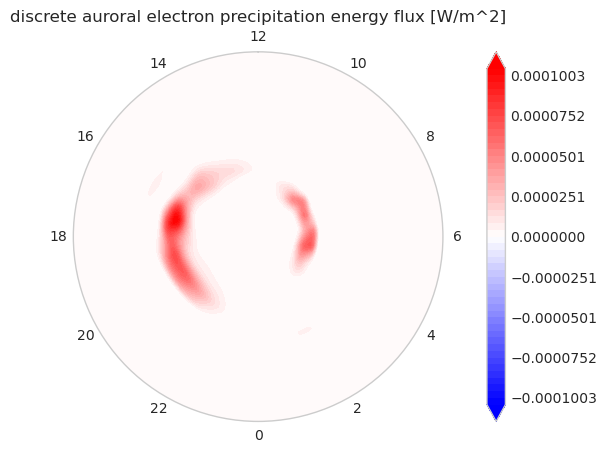

In [24]:
for i in range(1, time_max, 160):
    iof.isel(time=i).prec_e_fe_2.ggcm.plot()